<a href="https://colab.research.google.com/github/mittalarsh86-maker/Data_Science_Project/blob/main/covid19_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
df = pd.read_csv("covid_19_clean_complete.csv")

print(df.head())
print(df.info())

  Province/State Country/Region       Lat       Long        Date  Confirmed  \
0            NaN    Afghanistan  33.93911  67.709953  2020-01-22          0   
1            NaN        Albania  41.15330  20.168300  2020-01-22          0   
2            NaN        Algeria  28.03390   1.659600  2020-01-22          0   
3            NaN        Andorra  42.50630   1.521800  2020-01-22          0   
4            NaN         Angola -11.20270  17.873900  2020-01-22          0   

   Deaths  Recovered  Active             WHO Region  
0       0          0       0  Eastern Mediterranean  
1       0          0       0                 Europe  
2       0          0       0                 Africa  
3       0          0       0                 Europe  
4       0          0       0                 Africa  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

print(df.isnull().sum())

df.fillna('Unknown', inplace=True)

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64


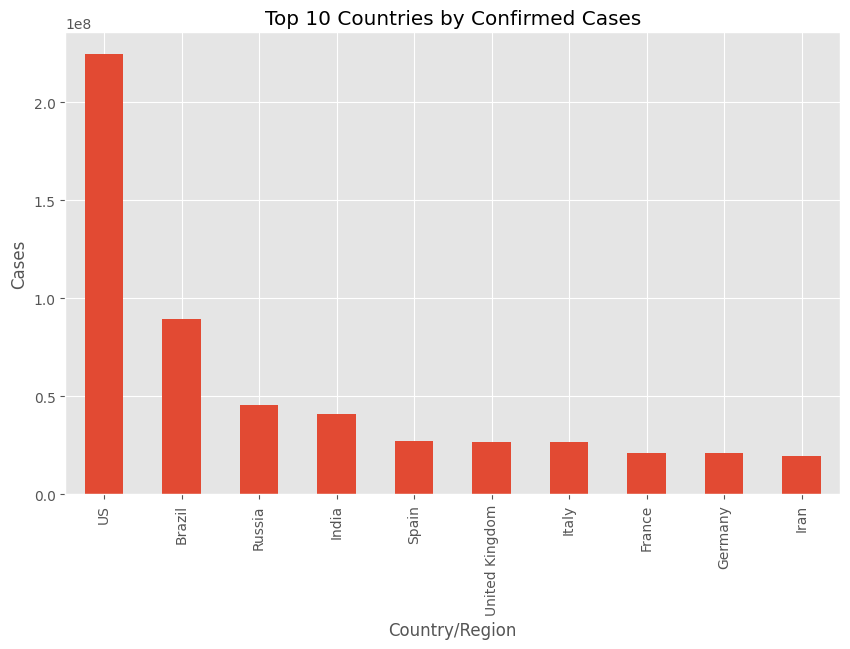

In [ ]:
top10 = df.groupby('Country/Region')['Confirmed'].sum() \
                 .sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='bar')

plt.title("Top 10 Countries by Confirmed Cases")
plt.ylabel("Cases")
plt.show()

In [ ]:
country_stats = df.groupby('Country/Region').agg({
    'Confirmed':'sum',
    'Recovered':'sum',
    'Deaths':'sum'
})

country_stats['Recovery Rate'] = (
    country_stats['Recovered'] /
    country_stats['Confirmed']
) * 100

country_stats['Death Rate'] = (
    country_stats['Deaths'] /
    country_stats['Confirmed']
) * 100

print(country_stats[['Recovery Rate','Death Rate']].head())

                Recovery Rate  Death Rate
Country/Region                           
Afghanistan         41.223101    2.535543
Albania             60.435074    2.901852
Algeria             64.072371    6.609169
Andorra             73.168510    5.744460
Angola              29.004501    4.756862


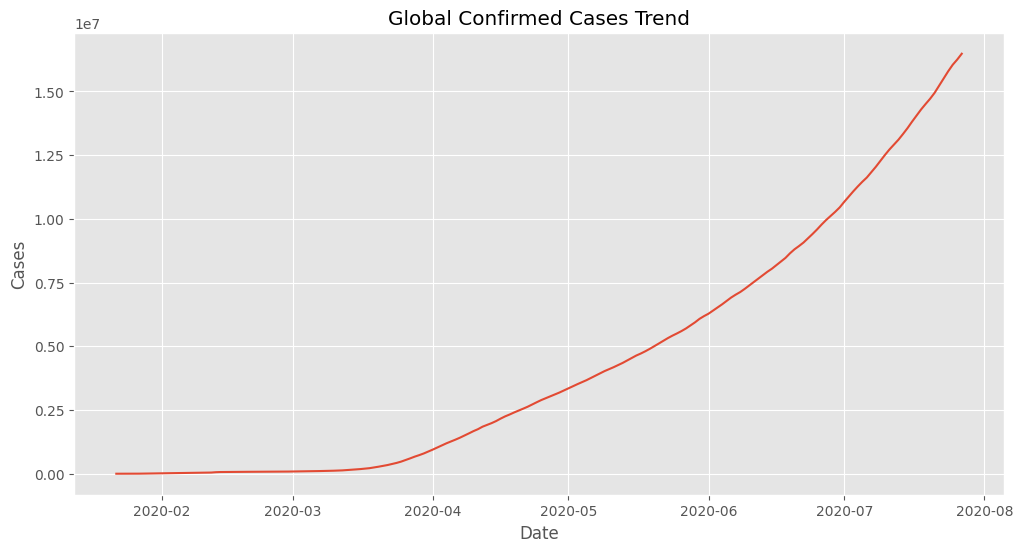

In [ ]:
global_cases = df.groupby('Date')['Confirmed'].sum()

plt.figure(figsize=(12,6))
plt.plot(global_cases)

plt.title("Global Confirmed Cases Trend")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

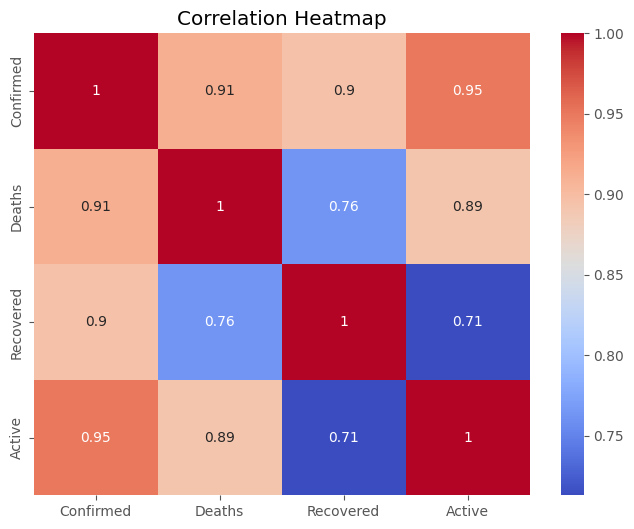

In [ ]:
corr = df[
    ['Confirmed',
     'Deaths',
     'Recovered',
     'Active']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()